In [1]:
import xarray as xr 
from anemoi.datasets import open_dataset
import numpy as np
import yaml
import os 
import csv
import cfgrib
from pathlib import Path
import pathlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import zarr
import matplotlib.patches as mpatches

## Visual of the domains

In [2]:
era5   = open_dataset("EGU26/Anemoidatasets/era5_A_large.zarr")
cerra  = open_dataset("EGU26/Anemoidatasets/Cerra_A_large.zarr")
farms  = pd.read_csv("/mnt/weatherloss/WindPower/data/NorthSea/Power/windfarm_metadata.csv")

In [3]:
time_idx      = 0
variable_name = "t2m"   # change as needed

var_idx_era5  = list(era5.variables).index(variable_name)
var_idx_cerra = list(cerra.variables).index(variable_name)

field_era5  = era5[time_idx][var_idx_era5, 0, :]
field_cerra = cerra[time_idx][var_idx_cerra, 0, :]

lons_era5  = era5.longitudes
lats_era5  = era5.latitudes
lons_cerra = cerra.longitudes
lats_cerra = cerra.latitudes
timestamp  = str(era5.dates[time_idx])

# ── Hardcoded CERRA bounding box ──────────────────────────────────────────────
lat_min, lat_max = lats_cerra.min(), lats_cerra.max()
lon_min, lon_max = lons_cerra.min(), lons_cerra.max()

box_lons = [lon_min, lon_max, lon_max, lon_min, lon_min]
box_lats = [lat_min, lat_min, lat_max, lat_max, lat_min]

outside = ~(
    (lats_era5 >= lat_min) & (lats_era5 <= lat_max) &
    (lons_era5 >= lon_min) & (lons_era5 <= lon_max)
)

vmin = np.nanpercentile(np.concatenate([field_era5, field_cerra]), 2)
vmax = np.nanpercentile(np.concatenate([field_era5, field_cerra]), 98)

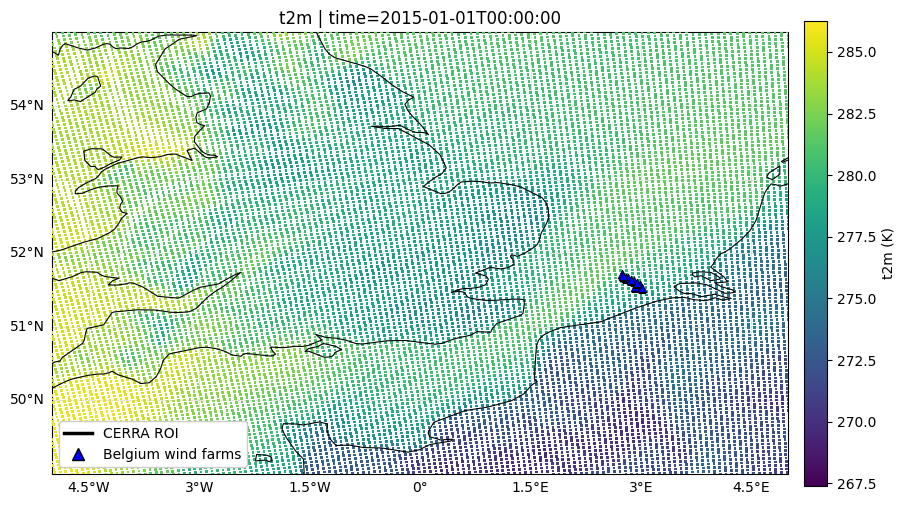

In [ ]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": proj})
ax.set_extent([-17, 16, 40, 66], crs=proj)

ax.scatter(lons_era5[outside], lats_era5[outside], c=field_era5[outside],
           cmap="viridis", vmin=vmin, vmax=vmax,
           s=20, marker="s", linewidths=0,
           transform=proj, rasterized=True, zorder=2)

sc = ax.scatter(lons_cerra, lats_cerra, c=field_cerra,
                cmap="viridis", vmin=vmin, vmax=vmax,
                s=4, marker="s", linewidths=0,
                transform=proj, rasterized=True, zorder=3)

# ── Wind farms ────────────────────────────────────────────────────────────────
colors = {"Belgium": "blue", "UK": "red"}
for region, group in farms.groupby("region"):
    ax.scatter(
        group["lon"], group["lat"],
        color=colors.get(region, "white"),
        s=40, marker="^", linewidths=0.6, edgecolors="black",
        transform=proj, zorder=6,
    )

ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8, edgecolor="black", zorder=4)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="grey", alpha=0.5, linestyle="--", zorder=3)
gl.top_labels   = False
gl.right_labels = False

ax.plot(box_lons, box_lats, color="black", linewidth=2.5, transform=proj, zorder=5)

handles = [mlines.Line2D([], [], color="black", lw=2.5, label="CERRA ROI")]
for region, color in colors.items():
    handles.append(mlines.Line2D([], [], marker="^", color="w",
                                  markerfacecolor=color, markeredgecolor="black",
                                  markersize=8, label=f"{region} wind farms"))
ax.legend(handles=handles, loc="lower left", framealpha=1.0, fontsize=10)

fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label=f"{variable_name} (K)", shrink=1.0, aspect=20)
ax.set_title(f"{variable_name} | time={timestamp}")
plt.savefig("ROI_large.png")
plt.show()

## Data/Power discrepancies

In [2]:
ds=xr.open_dataset("EGU26/cerra_EGULarge_xy.zarr")

In [9]:
import zarr
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

POWER_CSV = "/mnt/weatherloss/WindPower/data/NorthSea/Power/BE_UK_offshore_per_unit_3H_meanMW_shifted.csv"
META_CSV  = "/mnt/weatherloss/WindPower/data/NorthSea/Power/windfarm_metadata.csv"
OUT_ZARR  = "/mnt/weatherloss/WindPower/data/EGU26/cerra_EGULarge_xy.zarr"

power_df = pd.read_csv(POWER_CSV, index_col=0, parse_dates=True)
power_df.index = power_df.index.tz_localize(None)

meta = pd.read_csv(META_CSV)

lat2d = ds["latitude"].values
lon2d = ds["longitude"].values
ny, nx = lat2d.shape
tree = cKDTree(np.c_[lon2d.ravel(), lat2d.ravel()])
_, flat_idx = tree.query(np.c_[meta["lon"].values, meta["lat"].values])
meta["new_y"], meta["new_x"] = np.unravel_index(flat_idx, (ny, nx))

times = pd.to_datetime(ds["time"].values)
power_df = power_df.reindex(times)

cell_to_farms = meta.groupby(["new_y","new_x"]).apply(
    lambda g: list(zip(g["farm"], g["capacity_mw"]))
).to_dict()

# open zarr for writing
g = zarr.open_group(OUT_ZARR, mode="a")
power_arr = g["power"]  # shape (time, y, x)

n_cells_patched = 0
n_ts_nulled     = 0

for (y, x), farm_caps in sorted(cell_to_farms.items()):
    farms = [f for f, _ in farm_caps]
    cols  = [f for f in farms if f in power_df.columns]

    # only care about multi-farm cells
    if len(cols) < 2:
        continue

    # timesteps where ANY farm is NaN
    any_nan = power_df[cols].isna().any(axis=1).values  # (time,)
    n_nan   = any_nan.sum()

    if n_nan == 0:
        continue

    # read current power slice, set to NaN where any farm is missing, write back
    col = power_arr[:, y, x]
    col[any_nan] = np.nan
    power_arr[:, y, x] = col

    n_cells_patched += 1
    n_ts_nulled     += n_nan
    print(f"({y:3d},{x:3d}) patched {n_nan:,} timesteps  farms: {farms}")

zarr.consolidate_metadata(OUT_ZARR)
print(f"\nDone. {n_cells_patched} cells patched, {n_ts_nulled:,} total timesteps set to NaN.")

/tmp/ipykernel_328/1435802765.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_to_farms = meta.groupby(["new_y","new_x"]).apply(


(114,201) patched 15,103 timesteps  farms: ['Thorntonbank - C-Power - Area NE', 'Rentel Offshore WP']
(115,200) patched 17,108 timesteps  farms: ['Northwind', 'Seastar Offshore WP']
(116,199) patched 15,096 timesteps  farms: ['Belwind Phase 1', 'Nobelwind Offshore Windpark']
(119,179) patched 22,648 timesteps  farms: ['Galloper', 'GunfleetSands']
(161,130) patched 21,200 timesteps  farms: ['BurboBank', 'BurboBankExtension']
(162,190) patched 28,488 timesteps  farms: ['HornseaOne', 'HornseaTwo']
(172,127) patched 19,728 timesteps  farms: ['Walney1', 'Walney2']

Done. 7 cells patched, 139,371 total timesteps set to NaN.


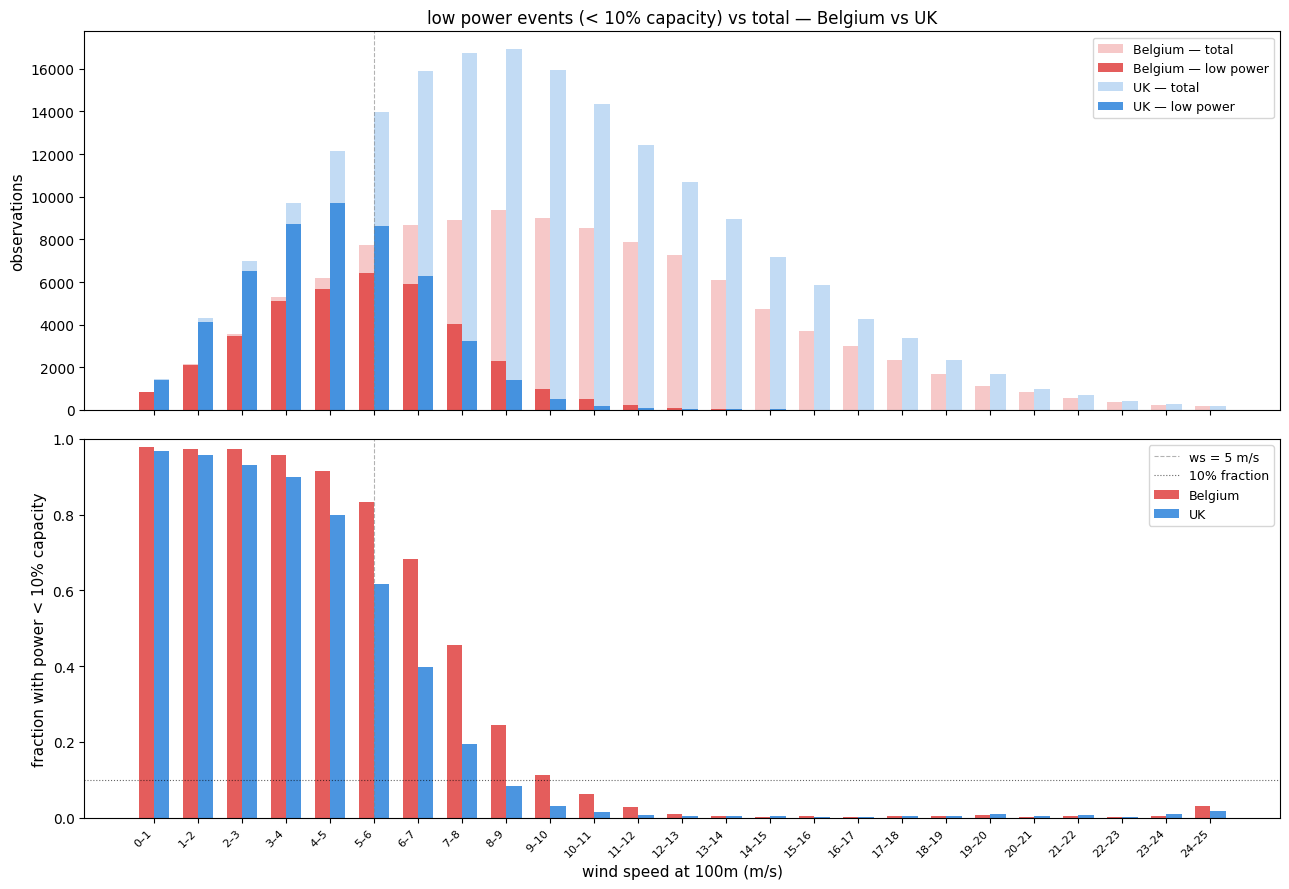

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

META_CSV = "/mnt/weatherloss/WindPower/data/NorthSea/Power/windfarm_metadata.csv"
meta = pd.read_csv(META_CSV)

lat2d = ds["latitude"].values
lon2d = ds["longitude"].values
ny, nx = lat2d.shape
tree = cKDTree(np.c_[lon2d.ravel(), lat2d.ravel()])
_, flat_idx = tree.query(np.c_[meta["lon"].values, meta["lat"].values])
meta["new_y"], meta["new_x"] = np.unravel_index(flat_idx, (ny, nx))

be_mask = np.zeros((ny, nx), dtype=bool)
uk_mask = np.zeros((ny, nx), dtype=bool)
for _, row in meta.iterrows():
    y, x = int(row["new_y"]), int(row["new_x"])
    if row["region"] == "Belgium":
        be_mask[y, x] = True
    elif row["region"] == "UK":
        uk_mask[y, x] = True

turbine_mask = (~np.isnan(ds["turbinemask"])) & (ds["capacity"] > 0)
power_ratio  = (ds["power"] / ds["capacity"]).values
ws           = ds["ws100"].values
tm_3d        = turbine_mask.values[np.newaxis, :, :]
be_mask_3d   = be_mask[np.newaxis, :, :]
uk_mask_3d   = uk_mask[np.newaxis, :, :]

bins = np.arange(0, 26, 1)

def get_counts(region_mask_3d):
    m      = tm_3d & region_mask_3d & np.isfinite(power_ratio) & np.isfinite(ws)
    ws_r   = ws[m]
    pr_r   = power_ratio[m]
    total, _ = np.histogram(ws_r,              bins=bins)
    low,   _ = np.histogram(ws_r[pr_r < 0.10], bins=bins)
    return total, low

total_be, low_be = get_counts(be_mask_3d)
total_uk, low_uk = get_counts(uk_mask_3d)

frac_be = np.where(total_be > 0, low_be / total_be, np.nan)
frac_uk = np.where(total_uk > 0, low_uk / total_uk, np.nan)

x     = np.arange(25)
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# ── top: raw counts stacked ───────────────────────────────────────────
ax1.bar(x - width/2, total_be, width, label='Belgium — total', color='#E24B4A', alpha=0.3)
ax1.bar(x - width/2, low_be,   width, label='Belgium — low power', color='#E24B4A', alpha=0.9)
ax1.bar(x + width/2, total_uk, width, label='UK — total', color='#378ADD', alpha=0.3)
ax1.bar(x + width/2, low_uk,   width, label='UK — low power', color='#378ADD', alpha=0.9)
ax1.axvline(x=5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
#ax1.set_yscale('log')
ax1.set_ylabel('observations', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_title('low power events (< 10% capacity) vs total — Belgium vs UK', fontsize=12)

# ── bottom: fraction ──────────────────────────────────────────────────
ax2.bar(x - width/2, frac_be, width, label='Belgium', color='#E24B4A', alpha=0.9)
ax2.bar(x + width/2, frac_uk, width, label='UK',      color='#378ADD', alpha=0.9)
ax2.axvline(x=5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='ws = 5 m/s')
ax2.axhline(y=0.10, color='black', linestyle=':', linewidth=0.8, alpha=0.6, label='10% fraction')
ax2.set_ylabel('fraction with power < 10% capacity', fontsize=11)
ax2.set_xlabel('wind speed at 100m (m/s)', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels([f'{i}–{i+1}' for i in range(25)], rotation=45, ha='right', fontsize=8)
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('wind_power_BE_UK.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd
import numpy as np

POWER_CSV = "/mnt/weatherloss/WindPower/data/NorthSea/Power/BE_UK_offshore_per_unit_3H_meanMW_shifted.csv"
power_df = pd.read_csv(POWER_CSV, index_col=0, parse_dates=True)
power_df.index = power_df.index.tz_localize(None)

META_CSV = "/mnt/weatherloss/WindPower/data/NorthSea/Power/windfarm_metadata.csv"
meta = pd.read_csv(META_CSV)

# re-snap to current grid
lat2d = ds["latitude"].values
lon2d = ds["longitude"].values
ny, nx = lat2d.shape
from scipy.spatial import cKDTree
tree = cKDTree(np.c_[lon2d.ravel(), lat2d.ravel()])
_, flat_idx = tree.query(np.c_[meta["lon"].values, meta["lat"].values])
meta["new_y"], meta["new_x"] = np.unravel_index(flat_idx, (ny, nx))

cell_to_farms = meta.groupby(["new_y","new_x"]).apply(
    lambda g: list(zip(g["farm"], g["capacity_mw"]))
).to_dict()

times = pd.to_datetime(ds["time"].values)
total_timesteps = len(times)

# align power_df to ds times
power_df = power_df.reindex(times)

print(f"Total timesteps in dataset: {total_timesteps:,}")
print(f"\n{'Cell':15s} {'farms':>6s} {'full_cap_MW':>11s} {'excluded_ts':>11s} {'excl_%':>7s}")
print("-" * 60)

total_cell_ts   = 0
total_excl_ts   = 0

for (y, x), farm_caps in sorted(cell_to_farms.items()):
    farms    = [f for f, _ in farm_caps]
    caps     = {f: c for f, c in farm_caps}
    cols     = [f for f in farms if f in power_df.columns]
    full_cap = sum(c for _, c in farm_caps)
    if not cols:
        continue

    lat = float(ds["latitude"][y, x])
    lon = float(ds["longitude"][y, x])

    eff_cap    = power_df[cols].notna().multiply([caps[f] for f in cols]).sum(axis=1)
    incomplete = (eff_cap < full_cap) & (eff_cap > 0)
    excl       = incomplete.sum()
    total_cell_ts += total_timesteps
    total_excl_ts += excl

    print(f"({y:3d},{x:3d}) lat={lat:6.2f} lon={lon:6.2f}  farms={len(farms):2d}  cap={full_cap:6.0f} MW  excluded={excl:6,}  ({100*excl/total_timesteps:5.1f}%)")

Total timesteps in dataset: 31,408

Cell             farms full_cap_MW excluded_ts  excl_%
------------------------------------------------------------
( 99,158) lat= 50.65 lon= -0.28  farms= 1  cap=   400 MW  excluded=     0  (  0.0%)
(113,200) lat= 51.52 lon=  2.91  farms= 1  cap=   163 MW  excluded=     0  (  0.0%)
(113,201) lat= 51.53 lon=  2.99  farms= 1  cap=   370 MW  excluded=     0  (  0.0%)
(114,201) lat= 51.58 lon=  2.98  farms= 2  cap=   471 MW  excluded=     7  (  0.0%)
(115,200) lat= 51.62 lon=  2.90  farms= 2  cap=   384 MW  excluded= 2,012  (  6.4%)
(116,198) lat= 51.67 lon=  2.73  farms= 1  cap=   218 MW  excluded=     0  (  0.0%)
(116,199) lat= 51.67 lon=  2.81  farms= 2  cap=   336 MW  excluded=     0  (  0.0%)
(117,183) lat= 51.66 lon=  1.54  farms= 1  cap=   630 MW  excluded=     0  (  0.0%)
(117,198) lat= 51.71 lon=  2.73  farms= 1  cap=   235 MW  excluded=     0  (  0.0%)
(119,179) lat= 51.74 lon=  1.20  farms= 2  cap=   526 MW  excluded= 2,920  (  9.3%)
(122,188

/tmp/ipykernel_328/3748711873.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_to_farms = meta.groupby(["new_y","new_x"]).apply(
